In [1]:
!apt-get update -qq && apt-get install -y ffmpeg -qq
!pip install -q ultralytics torchaudio pandas opencv-python scenedetect tqdm
!wget -q -O yolov8n-face.pt https://huggingface.co/junjiang/GestureFace/resolve/main/yolov8n-face.pt

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, bu

In [2]:
!ffmpeg -hide_banner -encoders | grep nvenc

 V....D h264_nvenc           NVIDIA NVENC H.264 encoder (codec h264)
 V..... nvenc                NVIDIA NVENC H.264 encoder (codec h264)
 V..... nvenc_h264           NVIDIA NVENC H.264 encoder (codec h264)
 V..... nvenc_hevc           NVIDIA NVENC hevc encoder (codec hevc)
 V....D hevc_nvenc           NVIDIA NVENC hevc encoder (codec hevc)


In [3]:
!ffmpeg -hide_banner -hwaccels

Hardware acceleration methods:
vdpau
cuda
vaapi
qsv
drm
opencl



In [4]:
%%writefile worker_module.py
import os, cv2, torch, subprocess
import numpy as np
from ultralytics import YOLO

VAD_MIN_DURATION = 2.0
VAD_MAX_DURATION = 12.0
WINDOW_SIZE = 5.0
WINDOW_STEP = 4.0
TAIL_MIN_DURATION = 2.5
YOLO_PASS_RATIO = 0.7
MIN_SPEECH_RATIO = 0.4
HISTOGRAM_CORRELATION_THRESHOLD = 0.6
AUDIO_BITRATE = "128k"
MIN_SNR = -999.0          

USE_NVENC          = True
USE_HWACCEL_DECODE = True
NVENC_CQ     = 23
NVENC_PRESET = "p4"
X264_CRF     = 18
X264_PRESET  = "veryfast"
YOLO_BATCH   = 256


def extract_audio(video_path, out_wav):
    subprocess.run([
        'ffmpeg', '-y', '-threads', '2', '-i', video_path,
        '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1',
        '-loglevel', 'error', out_wav
    ], capture_output=True)
    return os.path.exists(out_wav) and os.path.getsize(out_wav) > 0


def get_all_frames_1fps(video_path, gpu_id):
    hw = ['-hwaccel', 'cuda', '-hwaccel_device', str(gpu_id)] if USE_HWACCEL_DECODE else ['-threads', '2']
    cmd = ['ffmpeg', '-y', *hw, '-i', video_path,
           '-vf', 'fps=1,scale=320:320', '-f', 'rawvideo',
           '-pix_fmt', 'bgr24', '-loglevel', 'error', 'pipe:1']
    raw = subprocess.run(cmd, capture_output=True).stdout
    fs = 320 * 320 * 3
    n = len(raw) // fs
    return [np.frombuffer(raw[i*fs:(i+1)*fs], dtype=np.uint8).reshape(320, 320, 3).copy() for i in range(n)]


def build_chunks(start_sec, end_sec):
    dur = end_sec - start_sec
    chunks = []
    if dur < VAD_MIN_DURATION:
        return chunks
    if dur <= VAD_MAX_DURATION:
        chunks.append((start_sec, end_sec))
    else:
        s = start_sec
        while s + WINDOW_SIZE <= end_sec:
            chunks.append((s, s + WINDOW_SIZE))
            s += WINDOW_STEP
        if end_sec - s >= TAIL_MIN_DURATION:
            chunks.append((s, end_sec))
    return chunks


def check_scene_cut(frames):
    prev = None
    for frame in frames:
        hist = cv2.calcHist([frame], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
        if prev is not None and cv2.compareHist(prev, hist, cv2.HISTCMP_CORREL) < HISTOGRAM_CORRELATION_THRESHOLD:
            return True
        prev = hist
    return False


def speech_ratio_in_window(c_start, c_end, vad_segments):
    window = c_end - c_start
    if window <= 0:
        return 0.0
    overlap = 0.0
    for seg in vad_segments:
        lo = max(c_start, seg['start'] / 16000.0)
        hi = min(c_end, seg['end'] / 16000.0)
        if hi > lo:
            overlap += hi - lo
    return overlap / window


def build_snr_context(wav_np, vad_segments, sr=16000):
    """Tính 1 lần/video: power, speech_mask, và noise_floor.
    noise_floor = năng lượng trung bình của các đoạn KHÔNG phải speech (nhiễu nền thật)."""
    n = wav_np.size
    power = wav_np ** 2
    speech_mask = np.zeros(n, dtype=bool)
    for seg in vad_segments:
        a = max(0, int(seg['start']))
        b = min(n, int(seg['end']))
        if b > a:
            speech_mask[a:b] = True
    noise_samples = power[~speech_mask]
    if noise_samples.size < int(sr * 0.1):   # < 0.1s non-speech: không đủ tin cậy
        noise_floor = float(np.percentile(power, 5))   # fallback
    else:
        noise_floor = float(np.mean(noise_samples))
    return power, speech_mask, max(noise_floor, 1e-10)


def compute_snr(power, speech_mask, noise_floor, c_start, c_end, sr=16000):
    """SNR (dB) của clip = năng lượng phần speech trong clip / noise_floor toàn video."""
    a = int(c_start * sr)
    b = int(c_end * sr)
    seg_power = power[a:b]
    seg_speech = speech_mask[a:b]
    sig = seg_power[seg_speech]
    if sig.size == 0:
        return -np.inf
    signal_power = float(np.mean(sig))
    return 10.0 * np.log10(signal_power / noise_floor)


def cut_clip(video_path, clip_path, c_start, c_end, gpu_id):
    hw = ['-hwaccel', 'cuda', '-hwaccel_device', str(gpu_id)] if USE_HWACCEL_DECODE else []
    if USE_NVENC:
        vcodec = ['-c:v', 'h264_nvenc', '-preset', NVENC_PRESET, '-rc', 'vbr',
                  '-cq', str(NVENC_CQ), '-gpu', str(gpu_id), '-pix_fmt', 'yuv420p']
    else:
        vcodec = ['-c:v', 'libx264', '-crf', str(X264_CRF), '-preset', X264_PRESET]
    cmd = ['ffmpeg', '-y', *hw, '-ss', str(c_start), '-i', video_path,
           '-t', str(c_end - c_start), *vcodec,
           '-c:a', 'aac', '-b:a', AUDIO_BITRATE, '-loglevel', 'error', clip_path]
    subprocess.run(cmd, capture_output=True)
    return os.path.exists(clip_path) and os.path.getsize(clip_path) > 0


def detect_faces_batched(face_model, frames, gpu_id, batch=YOLO_BATCH):
    flags = []
    for i in range(0, len(frames), batch):
        res = face_model.predict(frames[i:i+batch], verbose=False,
                                 imgsz=320, half=True, device=gpu_id, stream=False)
        flags.extend(len(r.boxes) > 0 for r in res)
        del res
    return flags


_FACE_MODEL = None
_VAD_MODEL = None
_GET_SPEECH = None
_READ_AUDIO = None
_GPU_ID = 0


def init_worker(gpu_counter, num_gpus):
    global _FACE_MODEL, _VAD_MODEL, _GET_SPEECH, _READ_AUDIO, _GPU_ID
    with gpu_counter.get_lock():
        idx = gpu_counter.value
        gpu_counter.value += 1
    _GPU_ID = idx % num_gpus
    device = torch.device(f'cuda:{_GPU_ID}' if torch.cuda.is_available() else 'cpu')

    _FACE_MODEL = YOLO('yolov8n-face.pt')
    _FACE_MODEL.model = _FACE_MODEL.model.to(device)
    _FACE_MODEL.model.eval()

    vad_model, utils = torch.hub.load('snakers4/silero-vad', 'silero_vad',
                                      force_reload=False, trust_repo=True)
    _VAD_MODEL = vad_model.to(device).eval()
    _GET_SPEECH, _, _READ_AUDIO, _, _ = utils


def process_one_video(task):
    filename, dataset_dir, output_dir = task
    gpu_id = _GPU_ID
    device = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')

    valid_clips, reject_log = [], []
    video_path = os.path.join(dataset_dir, filename)
    video_id = os.path.splitext(filename)[0]
    temp_audio = f"/tmp/{video_id}_src_{os.getpid()}.wav"

    if not extract_audio(video_path, temp_audio):
        return [], [{'video': video_id, 'reason': 'audio_extract_failed'}]

    try:
        wav = _READ_AUDIO(temp_audio).to(device)
        vad_segments = _GET_SPEECH(wav, _VAD_MODEL, sampling_rate=16000)
    except Exception:
        if os.path.exists(temp_audio): os.remove(temp_audio)
        return [], [{'video': video_id, 'reason': 'vad_failed'}]

    if not vad_segments:
        if os.path.exists(temp_audio): os.remove(temp_audio)
        return [], [{'video': video_id, 'reason': 'no_speech_detected'}]
    
    # Audio -> numpy 1 lần; dựng context SNR 1 lần/video
    wav_np = wav.detach().cpu().numpy().astype(np.float32).flatten()
    snr_power, snr_speech_mask, snr_noise_floor = build_snr_context(wav_np, vad_segments)

    all_frames = get_all_frames_1fps(video_path, gpu_id)
    if not all_frames:
        if os.path.exists(temp_audio): os.remove(temp_audio)
        return [], [{'video': video_id, 'reason': 'video_decode_failed'}]

    frame_has_face = detect_faces_batched(_FACE_MODEL, all_frames, gpu_id)

    clip_idx = 0
    for seg in vad_segments:
        seg_start = seg['start'] / 16000.0
        seg_end = seg['end'] / 16000.0
        if (seg_end - seg_start) < VAD_MIN_DURATION:
            reject_log.append({'video': video_id, 'start': round(seg_start, 3),
                               'end': round(seg_end, 3), 'reason': 'segment_too_short'})
            continue

        for c_start, c_end in build_chunks(seg_start, seg_end):
            c_dur = c_end - c_start
            start_idx = int(c_start)
            end_idx = int(c_end)
            if end_idx == start_idx:
                end_idx += 1

            chunk_frames = all_frames[start_idx:end_idx]
            if not chunk_frames:
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'frame_extract_failed'})
                continue

            if check_scene_cut(chunk_frames):
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'scene_cut_detected'})
                continue

            face_flags = frame_has_face[start_idx:end_idx]
            if not face_flags:
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'face_index_oob'})
                continue
            face_ratio = sum(face_flags) / len(face_flags)
            if face_ratio < YOLO_PASS_RATIO:
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'face_density_low'})
                continue

            speech_ratio = speech_ratio_in_window(c_start, c_end, vad_segments)
            if speech_ratio < MIN_SPEECH_RATIO:
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'speech_low'})
                continue

            snr = compute_snr(snr_power, snr_speech_mask, snr_noise_floor, c_start, c_end)
            if snr < MIN_SNR:
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'snr_low', 'snr': round(snr, 2)})
                continue

            clip_name = f"{video_id}_clip{clip_idx:04d}_t{int(c_start):05d}.mp4"
            clip_path = os.path.join(output_dir, clip_name)
            if not cut_clip(video_path, clip_path, c_start, c_end, gpu_id):
                reject_log.append({'video': video_id, 'start': round(c_start, 3),
                                   'end': round(c_end, 3), 'reason': 'ffmpeg_cut_failed'})
                continue

            valid_clips.append({
                'clip_id': clip_name.replace('.mp4', ''),
                'source_video': video_id,
                'start_time': round(c_start, 3), 'end_time': round(c_end, 3),
                'duration': round(c_dur, 3), 'face_ratio': round(face_ratio, 3),
                'speech_ratio': round(speech_ratio, 3), 'snr': round(snr, 2),
                'file_path': clip_path
            })
            clip_idx += 1

    if os.path.exists(temp_audio): os.remove(temp_audio)
    return valid_clips, reject_log

Writing worker_module.py


In [5]:
!grep -n "def init_worker\|def process_one_video\|def worker_process" /kaggle/working/worker_module.py

149:def init_worker(gpu_counter, num_gpus):
167:def process_one_video(task):


In [6]:
import os, time, shutil
import pandas as pd
import multiprocessing as mp
import torch
from tqdm import tqdm
import worker_module
assert hasattr(worker_module, 'process_one_video'), "SAI BẢN: chạy lại cell %%writefile worker_module.py"
from worker_module import init_worker, process_one_video

TIER_NAME = "tier1"
DATASET_DIR = "/kaggle/input/datasets/xanhla/vn-av-df-data-tier-1/tier1"
INPUT_CSV = "/kaggle/input/datasets/xanhla/tier1-quality-gate-passed-csv/tier1_quality_gate_passed.csv"
WORKING_DIR = "/kaggle/working"
CLIPS_DIR = os.path.join(WORKING_DIR, "clips", TIER_NAME)
os.makedirs(CLIPS_DIR, exist_ok=True)

START_INDEX = 0
END_INDEX = 100
BATCH_TAG = f"{START_INDEX}_{END_INDEX}"
NUM_WORKERS = 4

CLIP_LOG_MAIN = os.path.join(WORKING_DIR, f"{TIER_NAME}_v3_clips_{BATCH_TAG}.csv")
REJECT_LOG_MAIN = os.path.join(WORKING_DIR, f"{TIER_NAME}_v3_rejects_{BATCH_TAG}.csv")

if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)
    torch.hub.load('snakers4/silero-vad', 'silero_vad', force_reload=False, trust_repo=True)

    num_gpus = max(torch.cuda.device_count(), 1)
    print("num_gpus =", num_gpus)

    try:
        passed_videos = pd.read_csv(INPUT_CSV)['filename'].tolist()
    except FileNotFoundError:
        passed_videos = []
    if not passed_videos:
        raise SystemExit("Khong co video")

    videos = passed_videos[START_INDEX:END_INDEX]
    tasks = [(v, DATASET_DIR, CLIPS_DIR) for v in videos]

    gpu_counter = mp.Value('i', 0)
    all_clips, all_rejects = [], []

    t0 = time.time()
    with mp.Pool(NUM_WORKERS, initializer=init_worker, initargs=(gpu_counter, num_gpus)) as pool:
        for vc, rj in tqdm(pool.imap_unordered(process_one_video, tasks),
                           total=len(tasks), desc="videos"):
            all_clips.extend(vc)
            all_rejects.extend(rj)

    if all_clips:
        pd.DataFrame(all_clips).to_csv(CLIP_LOG_MAIN, index=False)
    if all_rejects:
        pd.DataFrame(all_rejects).to_csv(REJECT_LOG_MAIN, index=False)

    print(f"Tổng: {len(all_clips)} clips | {len(all_rejects)} rejects")
    print(f"Thời gian: {(time.time()-t0)/60:.1f} phút")
    shutil.make_archive(os.path.join(WORKING_DIR, f"{TIER_NAME}_v3_clips_{BATCH_TAG}"), 'zip', CLIPS_DIR)
    print("Hoàn tất")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
num_gpus = 2


videos:   0%|          | 0/100 [00:00<?, ?it/s]Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master
videos: 100%|██████████| 100/100 [32:25<00:00, 19.45s/it] 


Tổng: 1236 clips | 1658 rejects
Thời gian: 32.4 phút
Hoàn tất


### 3 cells ở dưới dùng để check mức độ phân bổ SNR trên video, chạy cho vui không chạy cũng không sao.

Đang dùng: /kaggle/working/tier1_v3_clips_0_100.csv
count    1236.000000
mean       12.690372
std        10.189683
min       -16.420000
25%         5.040000
50%         9.195000
75%        18.500000
max        37.060000
Name: snr, dtype: float64

Quantiles:
0.05     2.7575
0.10     3.4000
0.25     5.0400
0.50     9.1950
0.75    18.5000
Name: snr, dtype: float64


<Axes: ylabel='Frequency'>

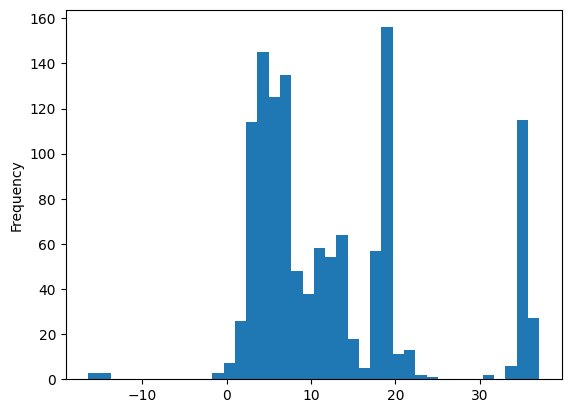

In [7]:
import pandas as pd
import glob, os

candidates = glob.glob("/kaggle/working/*_clips_*.csv")
candidates = [f for f in candidates if "_w" not in os.path.basename(f)] 
if not candidates:
    raise FileNotFoundError("Không tìm thấy file *_clips_*.csv trong /kaggle/working")
CLIPS_CSV = max(candidates, key=os.path.getmtime)
print("Đang dùng:", CLIPS_CSV)

df = pd.read_csv(CLIPS_CSV)
print(df['snr'].describe())
print("\nQuantiles:")
print(df['snr'].quantile([0.05, 0.10, 0.25, 0.50, 0.75]))
df['snr'].plot.hist(bins=40)

In [ ]:
import pandas as pd
from IPython.display import Audio, display

df = pd.read_csv(CLIPS_CSV)   

low = df[df['snr'] < 7]
high = df[df['snr'] > 11]

print("SNR thấp")
for _, row in low.sample(min(3, len(low))).iterrows():
    print(f"{row['clip_id']}  |  snr={row['snr']}")
    display(Audio(row['file_path']))

print("SNR cao")
for _, row in high.sample(min(3, len(high))).iterrows():
    print(f"{row['clip_id']}  |  snr={row['snr']}")
    display(Audio(row['file_path']))

In [ ]:
import pandas as pd

df = pd.read_csv(CLIPS_CSV)   
g = df.groupby('source_video')['snr'].agg(['mean', 'std', 'count'])
print(g.sort_values('mean'))